# Análise Exploratória de Negócio (Etapa 4)

Respostas às 5 perguntas de negócio do case, sobre o Data Warehouse dimensional em DuckDB:

1. Sazonalidade de faturamento e pedidos
2. Categorias mais rentáveis
3. Impacto do prazo de entrega na recompra
4. Customer Lifetime Value por macro-região
5. Concentração de vendas por vendedor (curva de Pareto)

O dimensionamento financeiro das alavancas derivadas destas análises está em
[`analise_alavancas.ipynb`](analise_alavancas.ipynb).

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

db_path = '../data/processed/olist.duckdb'
if not os.path.exists(db_path):
    db_path = 'data/processed/olist.duckdb'  # fallback se executado da raiz do projeto

conn = duckdb.connect(db_path, read_only=True)
print("Conexao com o DuckDB estabelecida.")

Conexao com o DuckDB estabelecida.


## 1. Sazonalidade de volume e faturamento

**Pergunta:** como o volume de pedidos e o faturamento se comportam ao longo do tempo?

Duas visões, porque um recorte só engana. A base cobre setembro de 2016 a setembro de 2018, então
somar todos os anos por número do mês coloca dois anos de dados em janeiro–agosto e apenas um em
setembro–dezembro. Nesse recorte, novembro de 2017 (o maior mês de toda a série) aparece *abaixo*
de maio, só porque maio tem o dobro de observações.

A visão (a) é a série temporal, que mostra tendência e o pico real. A visão (b) restringe aos meses
completos (jan/2017 a ago/2018) e divide pelo número de anos observados de cada mês.

Maior mes da serie: 2017-11 com 7,421 pedidos e R$ 1,003,862.14 de GMV
E a Black Friday de 2017 -- o unico novembro completo da base.


,mes,anos_observados,gmv_medio_ano
0,1,2,532777.28
1,2,2,541427.39
2,3,2,674696.19
3,4,2,673717.98
4,5,2,748015.47
5,6,2,646591.07
6,7,2,685165.78
7,8,2,708552.94
8,9,1,621415.91
9,10,1,660179.62


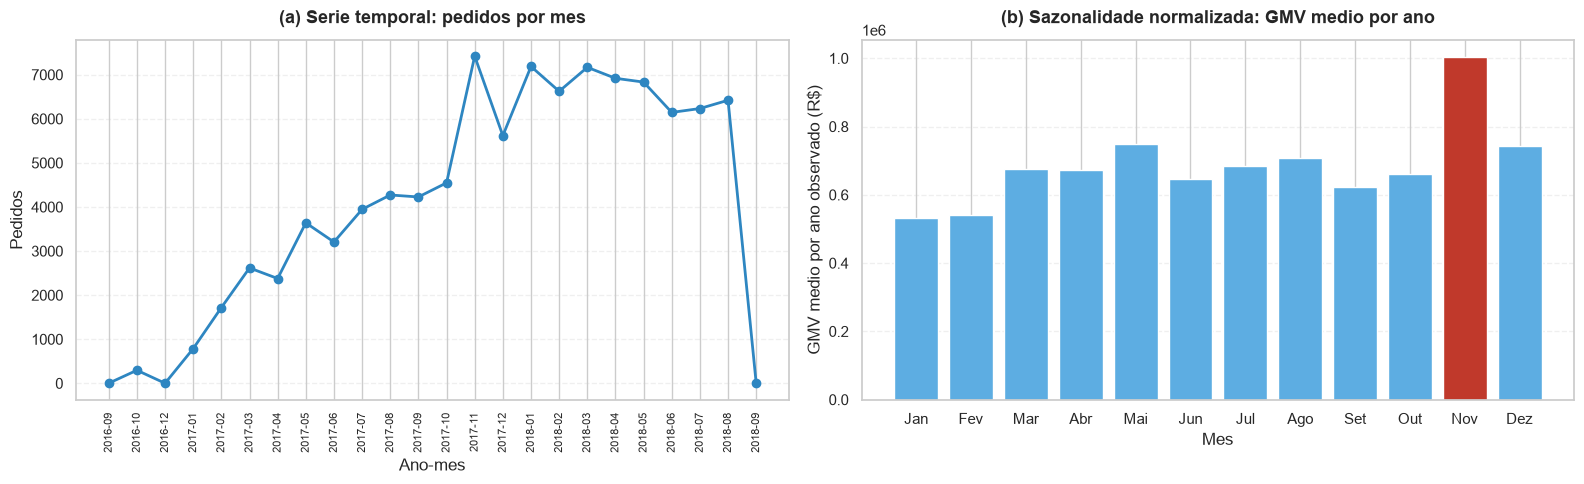

In [2]:
# (a) Serie temporal -- tendencia e pico real
query_serie = """
SELECT strftime(p.purchase_timestamp, '%Y-%m') AS ano_mes,
       COUNT(DISTINCT p.order_id) AS pedidos,
       ROUND(SUM(i.price), 2) AS gmv
FROM fato_pedidos p
JOIN fato_itens i ON p.order_id = i.order_id
GROUP BY 1 ORDER BY 1
"""
df_serie = conn.execute(query_serie).df()

# (b) Sazonalidade de calendario -- so meses completos, dividida pelos anos observados
query_sazonal = """
SELECT MONTH(p.purchase_timestamp) AS mes,
       COUNT(DISTINCT YEAR(p.purchase_timestamp)) AS anos_observados,
       ROUND(SUM(i.price) / COUNT(DISTINCT YEAR(p.purchase_timestamp)), 2) AS gmv_medio_ano
FROM fato_pedidos p
JOIN fato_itens i ON p.order_id = i.order_id
WHERE p.purchase_timestamp >= DATE '2017-01-01'
  AND p.purchase_timestamp <  DATE '2018-09-01'
GROUP BY 1 ORDER BY 1
"""
df_sazonal = conn.execute(query_sazonal).df()

pico = df_serie.loc[df_serie['pedidos'].idxmax()]
print(f"Maior mes da serie: {pico.ano_mes} com {pico.pedidos:,} pedidos e R$ {pico.gmv:,.2f} de GMV")
print("E a Black Friday de 2017 -- o unico novembro completo da base.")
display(df_sazonal)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(df_serie['ano_mes'], df_serie['pedidos'], marker='o', color='#2E86C1', linewidth=2)
ax[0].set_title('(a) Serie temporal: pedidos por mes', fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel('Ano-mes')
ax[0].set_ylabel('Pedidos')
ax[0].tick_params(axis='x', rotation=90, labelsize=8)
ax[0].grid(axis='y', linestyle='--', alpha=0.3)

meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
cores = ['#C0392B' if m == 11 else '#5DADE2' for m in df_sazonal['mes']]
ax[1].bar([meses[m - 1] for m in df_sazonal['mes']], df_sazonal['gmv_medio_ano'], color=cores)
ax[1].set_title('(b) Sazonalidade normalizada: GMV medio por ano', fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel('Mes')
ax[1].set_ylabel('GMV medio por ano observado (R$)')
ax[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusão.** A série cresce de forma consistente até o primeiro semestre de 2018, com novembro de
2017 (Black Friday) como pico absoluto de volume. Depois da normalização, novembro segue sendo o mês
mais forte do calendário. Janeiro mostra a desaceleração típica de pós-festas, e o segundo semestre
concentra os meses mais fortes, o que sugere planejar estoque e capacidade logística para o pico de novembro.

## 2. Categorias mais rentáveis

**Pergunta:** quais categorias lideram o faturamento, e qual a dinâmica de cada uma: volume ou ticket?

A tabela traz GMV, participação no total e preço médio por item. Produtos sem categoria cadastrada
ficam de fora do ranking (`categoria_informada`), porque `unknown` não é uma categoria de negócio.

In [10]:
query_categorias = """
SELECT
    p.category_name AS categoria,
    COUNT(*) AS itens_vendidos,
    ROUND(AVG(i.price), 2) AS preco_medio_item,
    ROUND(SUM(i.price), 2) AS gmv,
    ROUND(100.0 * SUM(i.price) / SUM(SUM(i.price)) OVER (), 1) AS pct_gmv
FROM fato_itens i
JOIN dim_produto p ON i.product_id = p.product_id
WHERE p.categoria_informada
GROUP BY 1
ORDER BY gmv DESC
"""
df_cat = conn.execute(query_categorias).df()
top10 = df_cat.head(10)
display(top10)

print(f"As 10 maiores categorias concentram {top10.pct_gmv.sum():.1f}% do GMV categorizado.")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].barh(top10['categoria'][::-1], top10['gmv'][::-1], color='#3498DB')
ax[0].set_title('Top 10 categorias por GMV', fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel('GMV (R$)')
ax[0].grid(axis='x', linestyle='--', alpha=0.3)

ax[1].barh(top10['categoria'][::-1], top10['preco_medio_item'][::-1], color='#E67E22')
ax[1].set_title('Preco medio por item nas mesmas categorias', fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel('Preco medio por item (R$)')
ax[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

ConnectionException: Connection Error: Connection already closed!

**Conclusão.** *health_beauty* lidera com 9,4% do GMV, seguida de *watches_gifts* (9,0%),
*bed_bath_table* (7,8%), *sports_leisure* (7,4%) e *computers_accessories* (6,8%).

Os dois gráficos lado a lado mostram que liderar o GMV não significa a mesma dinâmica comercial:
*bed_bath_table* aparece no topo por volume, com preço médio de R$ 93 por item, enquanto
*watches_gifts* chega quase ao mesmo GMV vendendo metade dos itens, a R$ 200 cada. É nas categorias
de ticket alto que o parcelamento estendido tem efeito, o que sustenta a Alavanca 1.

## 3. Impacto do prazo de entrega na recompra

**Pergunta:** o atraso na entrega do primeiro pedido reduz a chance de o cliente voltar a comprar?

**Resposta curta:** sim, com significância estatística e com magnitude pequena o suficiente para
não sustentar projeção de receita. As duas coisas são verdade ao mesmo tempo, e é por isso que a
pergunta merece as duas medidas.

Usamos o teste Qui-Quadrado cruzando pontualidade da primeira entrega com a ocorrência de recompra.
Depois testamos a versão mais ampla da hipótese: se a *satisfação* (nota da avaliação), e não só o
atraso, prevê recompra.

In [4]:
# Teste 1: atraso na 1a entrega vs recompra
query_retention = """
WITH primeiro AS (
    SELECT c.customer_unique_id,
           p.atrasou,
           ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY p.purchase_timestamp) AS rn
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered' AND p.atrasou IS NOT NULL
),
totais AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT p.order_id) AS n_pedidos
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered'
    GROUP BY 1
)
SELECT CASE WHEN pr.atrasou THEN 'Com atraso' ELSE 'No prazo' END AS status_1a_entrega,
       COUNT(*) AS clientes,
       SUM(CASE WHEN t.n_pedidos > 1 THEN 1 ELSE 0 END) AS recompraram,
       ROUND(100.0 * SUM(CASE WHEN t.n_pedidos > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS taxa_recompra_pct
FROM primeiro pr JOIN totais t USING (customer_unique_id)
WHERE pr.rn = 1
GROUP BY 1 ORDER BY 1
"""
df_retention = conn.execute(query_retention).df()
display(df_retention)

chi2, p_value, _, _ = chi2_contingency(
    [[r.recompraram, r.clientes - r.recompraram] for r in df_retention.itertuples()]
)
taxa_prazo = float(df_retention.query("status_1a_entrega == 'No prazo'")['taxa_recompra_pct'].iloc[0])
taxa_atraso = float(df_retention.query("status_1a_entrega == 'Com atraso'")['taxa_recompra_pct'].iloc[0])

print(f"Qui-Quadrado: {chi2:.4f}  |  p-valor: {p_value:.6f}")
print(f"Conclusao: {'rejeitamos' if p_value < 0.05 else 'nao rejeitamos'} a hipotese nula de independencia.")
print(f"Tamanho do efeito: {taxa_prazo - taxa_atraso:.2f} p.p. "
      f"(queda relativa de {(taxa_atraso / taxa_prazo - 1):.1%})")

# Prazo medio observado em cada grupo -- contexto da experiencia do cliente
display(conn.execute("""
    SELECT CASE WHEN atrasou THEN 'Com atraso' ELSE 'No prazo' END AS status,
           COUNT(*) AS pedidos,
           ROUND(AVG(prazo_entrega_dias), 1) AS prazo_medio_dias
    FROM fato_pedidos
    WHERE order_status = 'delivered' AND atrasou IS NOT NULL
    GROUP BY 1 ORDER BY 1
""").df())

,status_1a_entrega,clientes,recompraram,taxa_recompra_pct
0,Com atraso,7603,190.00,2.50
1,No prazo,85747,2611.00,3.05


Qui-Quadrado: 6.9667  |  p-valor: 0.008304
Conclusao: rejeitamos a hipotese nula de independencia.
Tamanho do efeito: 0.55 p.p. (queda relativa de -18.0%)


,status,pedidos,prazo_medio_dias
0,Com atraso,7826,31.50
1,No prazo,88644,10.80


,nota_1o_pedido,clientes,taxa_recompra_pct
0,1,9086,2.86
1,2,2833,2.75
2,3,7668,2.96
3,4,18366,2.78
4,5,54802,3.13


Amplitude entre a melhor e a pior nota: 0.38 p.p.


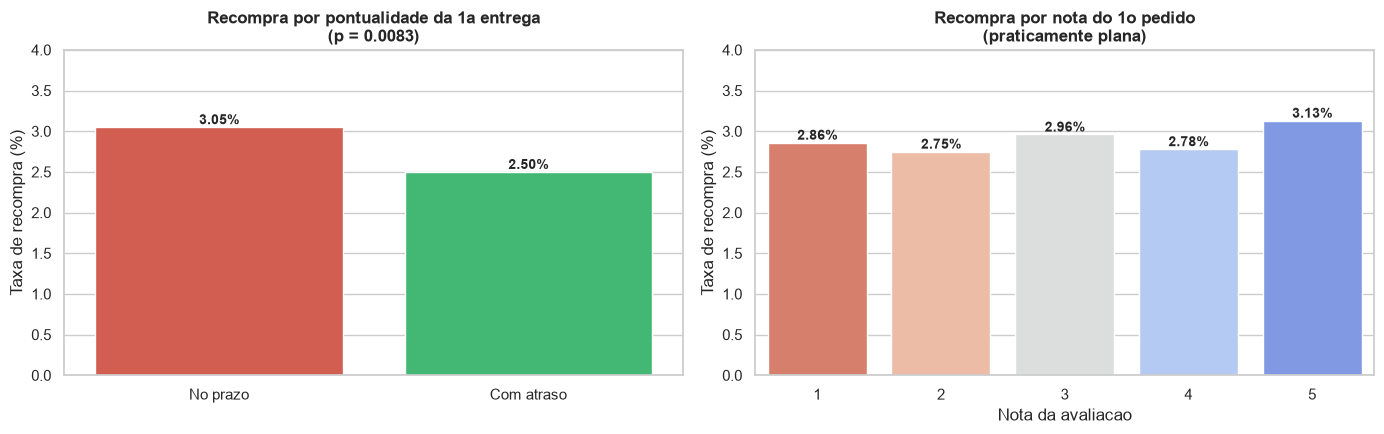


No limite: zerando TODOS os 4,008 atrasos de um semestre, o efeito de 0.55 p.p. preservaria cerca de 22 clientes.


In [5]:
# Teste 2: a nota da avaliacao preve recompra?
query_nota = """
WITH primeiro AS (
    SELECT c.customer_unique_id, p.review_score,
           ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY p.purchase_timestamp) AS rn
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered' AND p.review_score IS NOT NULL
),
totais AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT p.order_id) AS n_pedidos
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    WHERE p.order_status = 'delivered'
    GROUP BY 1
)
SELECT pr.review_score AS nota_1o_pedido, COUNT(*) AS clientes,
       ROUND(100.0 * SUM(CASE WHEN t.n_pedidos > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS taxa_recompra_pct
FROM primeiro pr JOIN totais t USING (customer_unique_id)
WHERE pr.rn = 1
GROUP BY 1 ORDER BY 1
"""
df_nota = conn.execute(query_nota).df()
display(df_nota)
print(f"Amplitude entre a melhor e a pior nota: "
      f"{df_nota.taxa_recompra_pct.max() - df_nota.taxa_recompra_pct.min():.2f} p.p.")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(data=df_retention, x='status_1a_entrega', y='taxa_recompra_pct',
            palette=['#E74C3C', '#2ECC71'], ax=ax[0], order=['No prazo', 'Com atraso'])
ax[0].set_title(f'Recompra por pontualidade da 1a entrega\n(p = {p_value:.4f})',
                fontsize=12, fontweight='bold')
ax[0].set_xlabel('')
ax[0].set_ylabel('Taxa de recompra (%)')
ax[0].set_ylim(0, 4)

sns.barplot(data=df_nota, x='nota_1o_pedido', y='taxa_recompra_pct', palette='coolwarm_r', ax=ax[1])
ax[1].set_title('Recompra por nota do 1o pedido\n(praticamente plana)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Nota da avaliacao')
ax[1].set_ylabel('Taxa de recompra (%)')
ax[1].set_ylim(0, 4)

for eixo in ax:
    for p in eixo.patches:
        eixo.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Quantos atrasos existem em um semestre -- serve de teto para o efeito acima
atrasos_semestre = conn.execute("""
    SELECT COUNT(*) FROM fato_pedidos
    WHERE order_status = 'delivered' AND atrasou
      AND YEAR(purchase_timestamp) = 2018 AND MONTH(purchase_timestamp) <= 6
""").fetchone()[0]
efeito_pp = taxa_prazo - taxa_atraso
print(f"\nNo limite: zerando TODOS os {atrasos_semestre:,} atrasos de um semestre, o efeito de "
      f"{efeito_pp:.2f} p.p. preservaria cerca de {atrasos_semestre * efeito_pp / 100:.0f} clientes.")

**Conclusão e por que ela importa para a recomendação.**

O atraso tem efeito real: quem recebeu com atraso esperou 31,5 dias em média contra 10,8 dias de quem
recebeu no prazo, e recompra menos, com o teste rejeitando a independência ($p < 0{,}01$).

Mas o efeito vale **0,55 ponto percentual**: 3,05% contra 2,50%. E o segundo teste mostra que a nota
da avaliação praticamente não move a recompra: a taxa fica entre 2,7% e 3,1% de 1 a 5 estrelas, com
nota 4 recomprando menos que nota 1.

A leitura correta é que **o Olist não tem massa de recompra suficiente para sustentar uma alavanca de
retenção**: 97% dos clientes compram uma única vez. Mesmo no cenário mais favorável possível, zerar
todos os 4.008 atrasos de um semestre, o ganho seria de cerca de 22 clientes, não centenas.

Por isso a Alavanca 2 do One-Pager foi redesenhada: em vez de projetar retenção, ela ataca a detração
pela causa-raiz, dimensionada por GMV exposto. O detalhamento está em `analise_alavancas.ipynb`.

## 4. Customer Lifetime Value por macro-região

**Pergunta:** qual o valor do cliente nas diferentes regiões do país?

**O limite do dado, declarado antes do resultado.** Com 97% de compradores únicos e uma janela de 24
meses, este dataset não sustenta um CLV no sentido próprio, não há ciclo de vida observável. O que
calculamos é o gasto acumulado, decomposto nos três pilares clássicos para deixar visível de onde vem
a diferença entre regiões:

$$\text{Gasto acumulado} = \text{Ticket Médio} \times \text{Frequência} \times \text{Retenção (meses)}$$

Agrupamos em 5 macro-regiões em vez das 27 UFs porque estados de baixa densidade produziam médias
instáveis, poucos clientes com ticket alto sendo lidos como "cliente mais valioso", quando o que
estava acontecendo era frete interestadual inflando o valor da transação.

,regiao,clientes,ticket_medio,frequencia,retencao_meses,recompra_pct
0,Norte,1786,225.51,1.03,1.08,2.74
1,Nordeste,9107,202.45,1.03,1.04,2.37
2,Centro-Oeste,5575,178.42,1.03,1.05,3.05
3,Sul,13634,163.37,1.03,1.07,2.95
4,Sudeste,65480,151.60,1.04,1.07,3.16


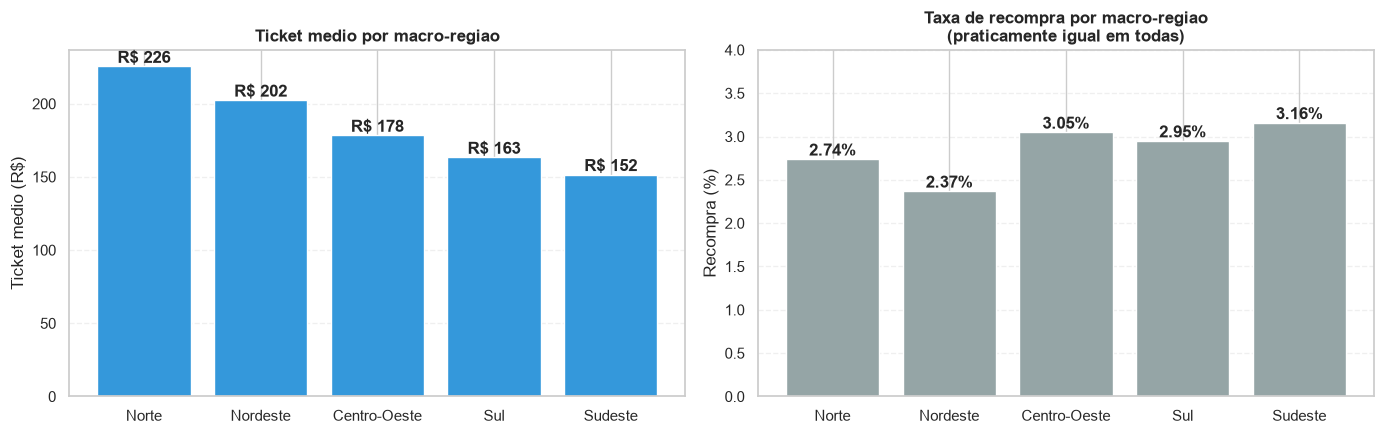

In [6]:
query_clv = """
WITH por_cliente AS (
    SELECT
        c.customer_unique_id,
        CASE
            WHEN c.state IN ('SP','RJ','MG','ES') THEN 'Sudeste'
            WHEN c.state IN ('PR','SC','RS') THEN 'Sul'
            WHEN c.state IN ('BA','PE','CE','MA','PB','RN','AL','PI','SE') THEN 'Nordeste'
            WHEN c.state IN ('DF','GO','MT','MS') THEN 'Centro-Oeste'
            WHEN c.state IN ('PA','AM','RO','TO','AC','AP','RR') THEN 'Norte'
            ELSE 'Outro'
        END AS regiao,
        COUNT(DISTINCT p.order_id) AS pedidos,
        SUM(pg.valor_pedido) AS gasto_total,
        -- retencao minima de 1 mes: quem comprou uma vez so tem 1 mes de "vida"
        GREATEST(1, DATE_DIFF('month', MIN(p.purchase_timestamp), MAX(p.purchase_timestamp))) AS meses_ativo
    FROM fato_pedidos p
    JOIN dim_cliente c ON p.customer_id = c.customer_id
    -- pagamentos agregados por pedido ANTES do join, para nao multiplicar linhas
    JOIN (SELECT order_id, SUM(payment_value) AS valor_pedido
          FROM fato_pagamentos GROUP BY 1) pg ON p.order_id = pg.order_id
    GROUP BY 1, 2
)
SELECT
    regiao,
    COUNT(*) AS clientes,
    ROUND(AVG(gasto_total / pedidos), 2) AS ticket_medio,
    ROUND(AVG(pedidos), 2) AS frequencia,
    ROUND(AVG(meses_ativo), 2) AS retencao_meses,
    ROUND(100.0 * SUM(CASE WHEN pedidos > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS recompra_pct
FROM por_cliente
GROUP BY 1
ORDER BY ticket_medio DESC
"""
df_clv = conn.execute(query_clv).df()
display(df_clv)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].bar(df_clv['regiao'], df_clv['ticket_medio'], color='#3498DB')
ax[0].set_title('Ticket medio por macro-regiao', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Ticket medio (R$)')
ax[0].grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(df_clv['ticket_medio']):
    ax[0].text(i, v, f'R$ {v:.0f}', ha='center', va='bottom', fontweight='bold')

ax[1].bar(df_clv['regiao'], df_clv['recompra_pct'], color='#95A5A6')
ax[1].set_title('Taxa de recompra por macro-regiao\n(praticamente igual em todas)',
                fontsize=12, fontweight='bold')
ax[1].set_ylabel('Recompra (%)')
ax[1].set_ylim(0, 4)
ax[1].grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(df_clv['recompra_pct']):
    ax[1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Síntese e conexão com a Alavanca 3.**

Norte e Nordeste apresentam os maiores tickets médios (R$ 225,51 e R$ 202,45 contra R$ 151,60 do
Sudeste), mas frequência e retenção são praticamente idênticas em todas as regiões, ~1,03 pedidos e
~1 mês. O contraste entre os dois gráficos é o achado: o ticket varia bastante entre regiões, a
recompra não varia quase nada.

Ou seja, o ticket mais alto do N/NE não é sinal de cliente mais fiel, e sim de compras maiores para
diluir frete elevado. Há apetite de consumo na região que a fricção logística limita, é esse
diagnóstico que sustenta a Alavanca 3 (ativação de oferta local no N/NE), cujo dimensionamento está
em `analise_alavancas.ipynb`.

## 5. Concentração de vendas e curva de Pareto de vendedores

**Pergunta:** a receita da plataforma depende de uma parcela pequena dos vendedores?

Reportamos três limiares em vez de um só, 50%, 70% e 80% da receita acumulada,porque um ponto
isolado da curva deixa a leitura incompleta, e é o de 80% que responde à pergunta no formato clássico
de Pareto.

,pct_receita,pct_sellers,n_sellers
0,50,4.22,129
1,70,11.26,344
2,80,17.67,540


Leitura de Pareto: 17.7% dos vendedores (540 de 3,056) geram 80% da receita.


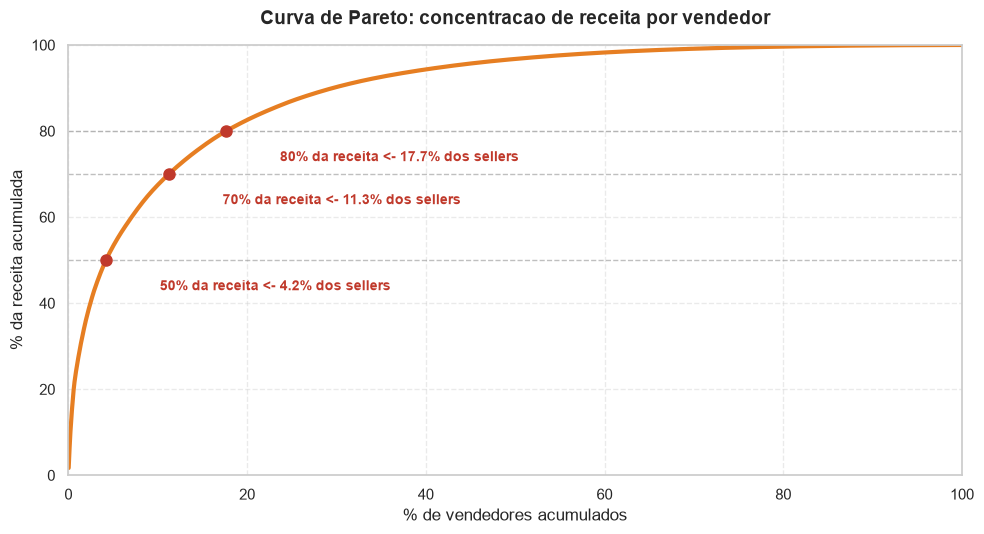

,faixa,sellers,pct_gmv
0,1. menos de 10 itens,1686,8.10
1,2. de 10 a 49,904,22.70
2,3. de 50 a 199,363,30.10
3,4. 200 itens ou mais,103,39.10


In [7]:
query_pareto = """
SELECT seller_id, SUM(price) AS receita
FROM fato_itens
GROUP BY 1 ORDER BY receita DESC
"""
df_pareto = conn.execute(query_pareto).df()

df_pareto['receita_acum_pct'] = 100 * df_pareto['receita'].cumsum() / df_pareto['receita'].sum()
df_pareto['sellers_acum_pct'] = 100 * np.arange(1, len(df_pareto) + 1) / len(df_pareto)

resumo = []
for alvo in [50, 70, 80]:
    ponto = df_pareto[df_pareto['receita_acum_pct'] >= alvo].iloc[0]
    resumo.append({'pct_receita': alvo,
                   'pct_sellers': round(ponto['sellers_acum_pct'], 2),
                   'n_sellers': int(round(ponto['sellers_acum_pct'] / 100 * len(df_pareto)))})
df_resumo = pd.DataFrame(resumo)
display(df_resumo)

p80 = df_resumo.query("pct_receita == 80").iloc[0]
print(f"Leitura de Pareto: {p80.pct_sellers:.1f}% dos vendedores ({int(p80.n_sellers)} de "
      f"{len(df_pareto):,}) geram 80% da receita.")

plt.figure(figsize=(10, 5.5))
plt.plot(df_pareto['sellers_acum_pct'], df_pareto['receita_acum_pct'], color='#E67E22', linewidth=3)
for _, ponto in df_resumo.iterrows():
    plt.axhline(ponto.pct_receita, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    plt.plot(ponto.pct_sellers, ponto.pct_receita, 'o', color='#C0392B', markersize=8)
    plt.annotate(f'{ponto.pct_receita:.0f}% da receita <- {ponto.pct_sellers:.1f}% dos sellers',
                 xy=(ponto.pct_sellers, ponto.pct_receita),
                 xytext=(ponto.pct_sellers + 6, ponto.pct_receita - 7),
                 fontsize=10, fontweight='bold', color='#C0392B')

plt.title('Curva de Pareto: concentracao de receita por vendedor', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% de vendedores acumulados')
plt.ylabel('% da receita acumulada')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# A cauda longa: quantos vendedores praticamente nao transacionam
display(conn.execute("""
    SELECT faixa, COUNT(*) AS sellers,
           ROUND(100.0 * SUM(gmv) / SUM(SUM(gmv)) OVER (), 1) AS pct_gmv
    FROM (
        SELECT seller_id, SUM(price) AS gmv,
               CASE WHEN COUNT(*) < 10 THEN '1. menos de 10 itens'
                    WHEN COUNT(*) < 50 THEN '2. de 10 a 49'
                    WHEN COUNT(*) < 200 THEN '3. de 50 a 199'
                    ELSE '4. 200 itens ou mais' END AS faixa
        FROM fato_itens GROUP BY 1
    )
    GROUP BY 1 ORDER BY 1
""").df())

**Conclusão.** A concentração é acentuada: menos de um quinto dos vendedores responde por 80% da
receita, e 4% deles já respondem pela metade. O outro lado dessa distribuição é uma cauda longa
improdutiva: 1.686 vendedores (55% da base com alguma venda) transacionaram menos de 10 itens em dois
anos e somam 8,1% do GMV.

Isso tem duas implicações opostas e ambas relevantes. Há risco de dependência concentrada em poucos
parceiros, e há um problema de ativação: cadastrar vendedor não é o mesmo que gerar receita. A segunda
implicação é o que disciplina o dimensionamento da Alavanca 3, ela projeta vendedores *ativados*, com
a taxa de ativação observada aqui, e não volume de cadastro.

In [8]:
conn.close()
print("Analise concluida e conexao encerrada.")

Analise concluida e conexao encerrada.
